In [1]:
import pandas as pd
import copy

from os import listdir, path
from os.path import isfile, join

from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

# from tabulate import tabulate
import numpy as np


from mpl_toolkits.axes_grid1.inset_locator import inset_axes 
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import make_interp_spline

In [2]:
# dataset_list = ['mnist','blog','income','cifar10']
dataset_list = ['aloi','blog','adult','syn','sensorless','covtype','helena','higgs_small']
# dataset_list = ['syn','cifar10']

In [5]:
allFiles=[]
for dataset in dataset_list :
    # mypath = "results/"+ dataset +"/"
    mypath = "results/"+ dataset +"/"
    onlyfiles = [mypath + f for f in listdir(mypath) if isfile(join(mypath, f))]
    onlyfiles = [f for f in onlyfiles if f[-3:] == "csv"]
    allFiles.extend(onlyfiles)
# allFiles


In [6]:
allFiles[0]

'results/aloi/Client-5-contrastive-50e-6fl-0.5mc-model_replacement_at-multi_krum_dt-0.8rl-aloi.csv'

In [10]:
for i, item in enumerate(allFiles):
    dt = pd.read_csv(item)
    dt["client"] = int(item.split("-")[1])
    # dt["type"] = item.split("-")[-1].split(".")[0]
    dt["epoch"] = int(item.split("-")[3][:-1])
    dt["fl"] = int(item.split("-")[4][:-2])
    dt["mc"] = float(item.split("-")[5][:-2])
    dt["at"] = str(item.split("-")[6][:-3])
    dt["rl"] = float(item.split("-")[7][:-2])
    dt["db"] = str(item.split("-")[8][:-4])
    dt["f1"] = dt.test_acc.apply(lambda x : eval(x)[-2])
    dt["accuracy"] = dt.test_acc.apply(lambda x : eval(x)[0])
    
    if i ==0 : db = dt
    else : db = pd.concat([db,dt])
# db = pd.merge(db[db.type == 'original'], db[db.type == 'contrastive'], on=["client","model"])
db = db[['client',	'epoch',	'fl',	'mc',	'at',	'rl',	'db','accuracy','f1']]
db = db[db.epoch == 50]
# db.head()

,client,epoch,fl,mc,at,dt,db,accuracy,f1
0,5,50,6,0.50,model_replacement,multi_krum_,aloi,0.640779,0.586748
0,1,50,6,0.00,scale,random_,aloi,0.381279,0.344122
0,2,50,6,0.25,scale,geometric_median_,aloi,0.509772,0.468049
0,1,50,6,0.50,model_replacement,multi_krum_,aloi,0.382089,0.350773
0,3,50,6,0.50,targeted,multi_krum_,aloi,0.408971,0.368297


In [58]:
# db.db.unique()

In [12]:
db['combined'] = db[[  'mc', 'rl']].apply(
    lambda x: '_'.join(x.astype(str)), axis=1
)
idx = [x+ '_' +item+'_'+str(n) for n in range(6) for item in db['at'].unique() for x in db.sort_values(['mc','rl'])['combined'].unique()]
idx = pd.DataFrame(idx, columns=['idx'])
# idx.shape

In [60]:
attackType=['scale','model_replacement','gradient_ascent','targeted']
malClient=[0.25,0.5,0.75]
randomLevel=[1,0.25,0.5,0.75]
idx_list=[]
for dt in dataset_list:
    for n in range(6):
        idx_list.append(['_'.join([dt,'scale',str(0.0),str(1.0),str(n)]),dt,'scale',0.0,1.0,n])
        for mc in malClient:
            for rl in randomLevel:
                for at in attackType:
                    idx_list.append(['_'.join([dt,at,str(mc),str(rl),str(n)]),dt,at,mc,rl,n])

idx_all = pd.DataFrame(idx_list, columns=['idx','db','at','mc','rl','client'])
idx_all.tail()
# print(idx_list)

,idx,db,at,mc,rl,client
2347,higgs_small_targeted_0.75_0.5_5,higgs_small,targeted,0.75,0.50,5
2348,higgs_small_scale_0.75_0.75_5,higgs_small,scale,0.75,0.75,5
2349,higgs_small_model_replacement_0.75_0.75_5,higgs_small,model_replacement,0.75,0.75,5
2350,higgs_small_gradient_ascent_0.75_0.75_5,higgs_small,gradient_ascent,0.75,0.75,5
2351,higgs_small_targeted_0.75_0.75_5,higgs_small,targeted,0.75,0.75,5


In [61]:
db['combined'] = db[[  'db','at','mc', 'rl','client']].apply(
    lambda x: '_'.join(x.astype(str)), axis=1
)
# db

In [62]:
dbx=idx_all.merge(db,left_on='idx', 
                          right_on='combined',
                          how='left')
dbx = dbx[['idx','client_x', 'mc_x', 'at_x', 'rl_x', 'db_x', 'accuracy','f1',]]
dbx.columns = ['idx','client', 'mc', 'at', 'rl', 'db', 'accuracy','f1',]
dbx.mc = dbx.mc.astype(float)
dbx.rl = dbx.rl.astype(float)
dbx.f1 = dbx.f1.astype(float)
dbx.f1 = dbx.f1.apply(lambda x : x if x>0 else np.nan)
dbx['nl'] = dbx.f1.isna()

dbx['nnl'] = dbx.f1.notna()
# dbx[dbx.db=='aloi']['at'].unique()

## Explore

In [63]:
def printDb(dataset,dbn):
# dataset = 'aloi'
    print('Dataset used:', dataset)
    dbx = dbn[dbn.db==str(dataset)]
    dbx = dbx.drop(
        dbx.query("mc == '0.0' and at!= 'scale'").index
    )
    print(dbx['at'].unique())
    dbNl = dbx[['mc','rl','at','nl']].pivot_table(
                    values='nl', 
                    index=['mc','rl',],
                    columns='at',
                    aggfunc='sum').reset_index().astype('float')
    print('***Fail Matrix***')
    print(dbNl)
    print(dbNl[['mc','scale', 'model_replacement', 'gradient_ascent', 'targeted']].groupby('mc').sum()/24)
    print(dbNl[['rl','scale', 'model_replacement', 'gradient_ascent', 'targeted']].groupby('rl').sum() / 24)
    # dbNnl = 
    dbx.f1 = dbx.f1.apply(lambda x : x if x>0 else np.nan)
    dbF1 = dbx[['mc','rl','at','f1']].pivot_table(
                    values='f1', 
                    index=['mc','rl',],
                    columns='at',
                    aggfunc='mean').reset_index().astype('float')
    print('***F1 Matrix***')
    print(dbF1)
    print(dbF1[['mc','model_replacement', 'gradient_ascent', 'targeted']].groupby('mc').mean())
    print(dbF1[['rl','model_replacement', 'gradient_ascent', 'targeted']].groupby('rl').mean())
    print('***End of Matrixs***')


# printDb('helena',dbx)

In [64]:
# for item in dataset_list:
#     printDb(item)
# db[(db['at']=='scale')&(db.db=='syn')&(db.mc==0.0)&(db.rl==1.0)]

In [65]:
# db['at'].unique()

In [66]:
# attack = 'scale'
def printAttack(attack):
    print('Attack Type:',attack)
    dbAt = dbx[dbx['at']==attack]
    # dbAt.f1 = dbAt.f1.apply(lambda x : x if x>0 else np.nan)
    # dbAt['nl'] = dbAt.f1.isna()
    # dbAt['nnl'] = dbAt.f1.notna()
    
    print('***ASR Matrix***')
    dbAt_ = dbAt.query("mc != 0.0")
    dbAt_
    dbAt_ = dbAt_[['mc','rl','db','nl']].pivot_table(
                        values='nl', 
                        index=['mc','rl',],
                        columns='db',
                        aggfunc='sum').reset_index().astype('float')
    
    print(dbAt_.to_latex(index=False,formatters={"name": str.upper},
                  float_format="{:.1f}".format,))
    print((dbAt_[['mc','adult','aloi','blog','covtype','helena','higgs_small','sensorless','syn']].groupby('mc').sum()/24).to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,))
    print((dbAt_[['rl','adult','aloi','blog','covtype','helena','higgs_small','sensorless','syn']].groupby('rl').sum() / 18).to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,))
    
    print('***F1 Matrix***')
    
    dbAt_ = dbAt[['mc','rl','db','f1']].pivot_table(
                        values='f1', 
                        index=['mc','rl',],
                        columns='db',
                        aggfunc='mean').reset_index().astype('float')
    print(dbAt_.to_latex(index=False,formatters={"name": str.upper},
                  float_format="{:.1f}".format,))
    print(dbAt_[['mc','adult','blog','helena','sensorless','syn']].groupby('mc').mean().to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,))
    print(dbAt_[['rl','adult','blog','helena','sensorless','syn']].groupby('rl').mean().to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,))
    
    
    print('***End Matrix***')

# printAttack('model_replacement')

In [67]:
db['at'].unique()

array(['scale', 'direction', 'model_replacement', 'targeted',
       'gradient_ascent'], dtype=object)

In [68]:
# for item in db['at'].unique():
#     printAttack(item)
# printAttack('gradient_ascent')

In [69]:
dbR = dbx[['rl','nl','db']].pivot_table(
                        values='nl', 
                        index=['rl',],
                        columns='db',
                        aggfunc='sum').reset_index().astype('float').set_index('rl')

In [70]:
dbR_ = dbx[['rl','mc','db']].pivot_table(
                        values='mc', 
                        index=['rl',],
                        columns='db',
                        aggfunc='count').reset_index().astype('float').set_index('rl')
    

In [71]:
# (dbR / dbR_ *100).plot(subplots=False, kind='bar')

In [72]:
# dbR.plot(subplots=False, kind='bar')

In [73]:
dbF1 = dbx[['rl','f1','db']].pivot_table(
                        values='f1', 
                        index=['rl',],
                        columns='db',
                        aggfunc='mean').reset_index().astype('float').set_index('rl')

In [74]:
# 

In [75]:
# import matplotlib.pyplot as plt
# fig, axs = plt.subplots(4, 2, sharex=True,)
# for i,ax in enumerate(axs.flat):
#     ax.plot(dbF1.index,dbF1[dbF1.columns[i]])
# plt.tight_layout()

In [76]:
db_m = dbR /dbR_

In [77]:
db_m

db,adult,aloi,blog,covtype,helena,higgs_small,sensorless,syn
rl,,,,,,,,
0.25,0.166667,0.500000,0.166667,0.333333,0.166667,0.250000,0.166667,0.166667
0.50,0.166667,0.652778,0.166667,1.000000,0.166667,0.250000,0.166667,0.166667
0.75,0.166667,1.000000,0.166667,1.000000,0.166667,0.250000,0.166667,0.166667
1.00,0.923077,0.923077,0.923077,0.923077,0.923077,0.923077,0.923077,0.923077


In [78]:
dbF1 = dbF1.fillna(dbF1.mean())

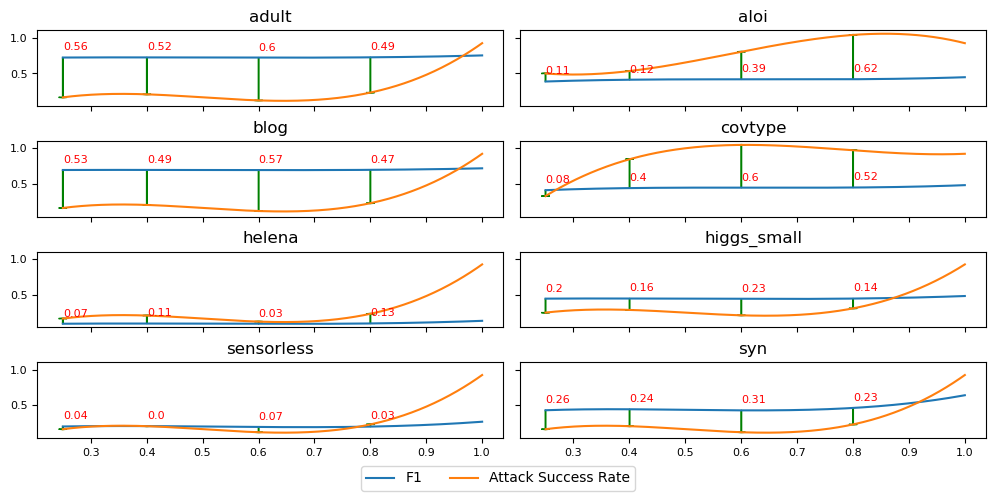

In [79]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 8          # Default font size for text
plt.rcParams['axes.titlesize'] = 12    # Font size for titles
plt.rcParams['axes.labelsize'] = 10      # Font size for x and y labels
plt.rcParams['xtick.labelsize'] = 8     # Font size for x-axis ticks
plt.rcParams['ytick.labelsize'] = 8     # Font size for y-axis ticks
plt.rcParams['legend.fontsize'] = 10 


fig, axs = plt.subplots(4, 2, sharex=True,figsize=(10, 5), sharey=True)
for i,ax in enumerate(axs.flat):
    X_Y_Spline = make_interp_spline(dbF1.index,dbF1[dbF1.columns[i]])
    X_ = np.linspace(dbF1.index.min(), dbF1.index.max(), 500)
    Y_ = X_Y_Spline(X_)
    ax.plot(X_,Y_, label='F1')
    XYSpline = make_interp_spline(db_m.index,db_m[dbF1.columns[i]])
    X = np.linspace(db_m.index.min(), db_m.index.max(), 500)
    Y = XYSpline(X)
    ax.plot(X,Y,label='Attack Success Rate')
    ax.set_title( dbF1.columns[i])
    for item in [0.2,0.4,0.6,0.8]:
        index = np.where(X_ > item)[0][0]
        # print(index)
        dist = Y[index] - Y_[index]
        ax.arrow(X_[index], Y_[index], 0, dist, 
                  head_width=0.015, head_length=0.005, 
                  fc='green', ec='green')
        ax.text(X_[index], Y_[index]+0.1, round(abs(dist),2), color='red')
        ax.legend().set_visible(False)
    
# ax.legend(loc='lower center', bbox_to_anchor=(0.5, 0), 
#            ncol=4, frameon=True, title='Functions')
handles, labels = [], []
for i,ax in enumerate(axs.flat):
    for handle, label in zip(*ax.get_legend_handles_labels()):
        handles.append(handle)
        labels.append(label)
        
handles, labels = handles[-2:], labels[-2:]
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0), 
           ncol=4, frameon=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)

plt.savefig('conclusion.png', dpi=300, bbox_inches='tight')

In [39]:
dbx.query('mc==0.0')[['rl','f1']].groupby('rl').mean()

,f1
rl,
1.0,0.491678


In [40]:
((0.491678 - dbx.query('mc!=0.0')[['rl','f1']] .groupby('rl').mean() ) / 0.489117).reset_index()

,rl,f1
0,0.25,0.132353
1,0.50,0.122056
2,0.75,0.119533
3,1.00,NaN


In [41]:
db_r1 = ((0.489117 - dbx.query('mc!=0.0 ')[['rl','f1']] .groupby('rl').mean() ) / 0.489117).reset_index()
db_r1.loc[3,'f1'] = 1.0
X_Y_Spline = make_interp_spline(db_r1.rl,db_r1.f1)
X_ = np.linspace(db_r1.rl.min(), db_r1.rl.max(), 10)
Y_ = X_Y_Spline(X_)
pd.DataFrame(np.round(Y_,3),np.round(X_,3), columns=['y'])

,y
0.250,0.127
0.333,0.177
0.417,0.163
0.500,0.117
0.583,0.072
0.667,0.060
0.750,0.114
0.833,0.267
0.917,0.552
1.000,1.000


In [348]:
dbx.query('mc==0.0')[['rl','nl']].groupby('nl').sum()

,rl
nl,
False,48.0


In [359]:
((dbx.query('mc!=0.0')[['rl','nl']] .groupby('rl').sum() ) /576).reset_index()

,rl,nl
0,0.25,0.229167
1,0.50,0.229167
2,0.75,0.229167
3,1.00,1.000000


In [360]:
db_r1 = ((dbx.query('mc!=0.0')[['rl','nl']] .groupby('rl').sum() ) /576).reset_index()
# db_r1.loc[3,'f1'] = 1.0
X_Y_Spline = make_interp_spline(db_r1.rl,db_r1.nl)
X_ = np.linspace(db_r1.rl.min(), db_r1.rl.max(), 10)
Y_ = X_Y_Spline(X_)
pd.DataFrame(np.round(Y_,3),np.round(X_,3), columns=['y'])

,y
0.250,0.229
0.333,0.277
0.417,0.267
0.500,0.229
0.583,0.191
0.667,0.182
0.750,0.229
0.833,0.362
0.917,0.610
1.000,1.000


In [377]:
dbx.query('rl==1.0 and mc != 0.0')[['db','f1']].groupby('db').mean()

,idx,client,mc,at,rl,db,accuracy,f1,nl,nnl
1,aloi_scale_0.25_1_0,0,0.25,scale,1.0,aloi,NaN,NaN,True,False
2,aloi_model_replacement_0.25_1_0,0,0.25,model_replacement,1.0,aloi,NaN,NaN,True,False
3,aloi_gradient_ascent_0.25_1_0,0,0.25,gradient_ascent,1.0,aloi,NaN,NaN,True,False
4,aloi_targeted_0.25_1_0,0,0.25,targeted,1.0,aloi,NaN,NaN,True,False
17,aloi_scale_0.5_1_0,0,0.50,scale,1.0,aloi,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...
2323,higgs_small_targeted_0.5_1_5,5,0.50,targeted,1.0,higgs_small,NaN,NaN,True,False
2336,higgs_small_scale_0.75_1_5,5,0.75,scale,1.0,higgs_small,NaN,NaN,True,False
2337,higgs_small_model_replacement_0.75_1_5,5,0.75,model_replacement,1.0,higgs_small,NaN,NaN,True,False
2338,higgs_small_gradient_ascent_0.75_1_5,5,0.75,gradient_ascent,1.0,higgs_small,NaN,NaN,True,False
